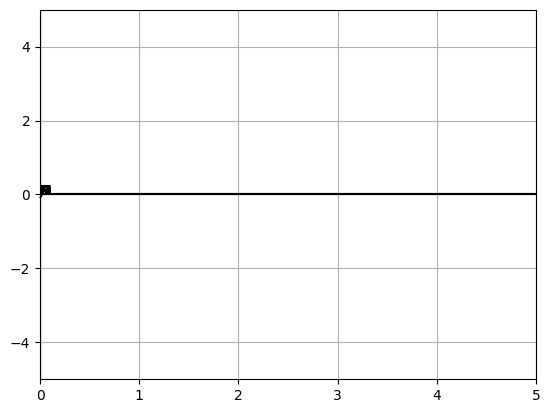

In [6]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

points = {
    "A": (2, 3), "B": (2, 4), "C": (3, 4), "D": (3, 3),
    "E": (2, -3), "F": (3, -3), "G": (2, -4), "H": (3, -4),
    "I": (2, 2), "J": (3, 2), "K": (2, 1), "L": (3, 1),
    "M": (2, -1), "N": (3, -1), "O": (2, -2), "P": (3, -2)
}

boxes = [
    ["A", "B", "C", "D", "A"],
    ["E", "F", "H", "G", "E"],
    ["I", "J", "L", "K", "I"],
    ["M", "N", "P", "O", "M"]
]

fig, ax = plt.subplots()

# Inisialisasi awal agar tidak perlu clear sumbu setiap saat
lines = [ax.plot([], [], color="blue")[0] for _ in boxes]
scat = ax.scatter([], [], color="red")
texts = [ax.text(0, 0, nama) for nama in points.keys()]

def init():
    ax.set_xlim(0, 5)
    ax.set_ylim(-5, 5)
    ax.axhline(0, color="black")
    ax.axvline(0, color="black")
    ax.grid(True)
    return lines + [scat] + texts

def update(frame):
    scale_y = 1 - frame / 100
    
    current_x, current_y = [], []
    
    # Update garis kotak
    for i, box in enumerate(boxes):
        x_vals = [points[p][0] for p in box]
        y_vals = [points[p][1] * scale_y for p in box]
        lines[i].set_data(x_vals, y_vals)
        
    # Update titik dan teks
    for i, (nama, (x, y)) in enumerate(points.items()):
        new_y = y * scale_y
        texts[i].set_position((x + 0.05, new_y + 0.05))
        current_x.append(x)
        current_y.append(new_y)
    
    scat.set_offsets(list(zip(current_x, current_y)))
    
    return lines + [scat] + texts

# Simpan ke variabel 'ani' agar tidak terkena garbage collection
ani = animation.FuncAnimation(
    fig, update, frames=101, init_func=init, 
    interval=50, blit=True
)

plt.show()